# **Project Name**    - **Tata Steel Machine Failure Prediction (EDA)**



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on performing Exploratory Data Analysis (EDA) on an industrial predictive maintenance dataset to understand machine behavior, data quality, and failure patterns. The primary goal of this phase is to gain insights from the data and prepare a strong foundation for subsequent machine learning modeling.

The dataset consists of 136,429 observations and 14 features, including machine identifiers, machine type, environmental and operational parameters such as air temperature, process temperature, rotational speed, torque, and tool wear. It also includes a binary target variable, Machine failure, along with multiple failure-type indicators.

EDA began with a structural assessment of the dataset, confirming that the data is clean, well-structured, and free from missing values. Data type analysis identified a mix of numerical, categorical, and binary variables. Descriptive statistics were used to understand central tendency, spread, and ranges of numerical features.
A key insight from the analysis was the severe class imbalance in the target variable, where machine failures represent a very small proportion of the data. This finding highlights the need for specialized evaluation metrics and imbalance-handling techniques in later modeling stages.

Univariate analysis revealed that temperature-related features have stable distributions, while operational parameters such as rotational speed, torque, and tool wear exhibit wider variability, making them potentially strong indicators of machine failure. Failure-type variables were found to be rare events, reinforcing the complexity of failure prediction.

Limited and safe checks were performed on the test dataset to ensure schema consistency and detect potential data drift without causing data leakage. Overall, the EDA phase provided critical insights into data distribution, feature relevance, and challenges such as imbalance, guiding informed decisions for preprocessing and modeling.

# **GitHub Link -**

https://github.com/srushtivarpe


# **Problem Statement**


To perform Exploratory Data Analysis on a predictive maintenance dataset in order to understand data quality, feature distributions, relationships among variables, and failure patterns, and to identify challenges such as class imbalance that influence further machine learning modeling.

#### **Define Your Business Objective?**

To gain actionable insights from historical machine data through exploratory data analysis, enabling organizations to recognize failure patterns, assess data quality, and prepare reliable inputs for predictive maintenance solutions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [2]:
# Load Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset First View

In [4]:
# Dataset First Look
data = pd.read_csv('/content/drive/MyDrive/Module 5/train.csv')

In [5]:
data

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136424,136424,M22284,M,300.1,311.4,1530,37.5,210,0,0,0,0,0,0
136425,136425,H38017,H,297.5,308.5,1447,49.1,2,0,0,0,0,0,0
136426,136426,L54690,L,300.5,311.8,1524,38.5,214,0,0,0,0,0,0
136427,136427,L53876,L,301.7,310.9,1447,46.3,42,0,0,0,0,0,0


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print('Rows and columns in data file:',data.shape)

Rows and columns in data file: (136429, 14)


### Dataset Information

In [7]:
# Dataset Info
print('Information about data file:')
data.info()

Information about data file:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      13642

#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
print('Duplicate values in data file:',data.duplicated().sum())

Duplicate values in data file: 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
missing_data=data.isnull().sum()
missing_data

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


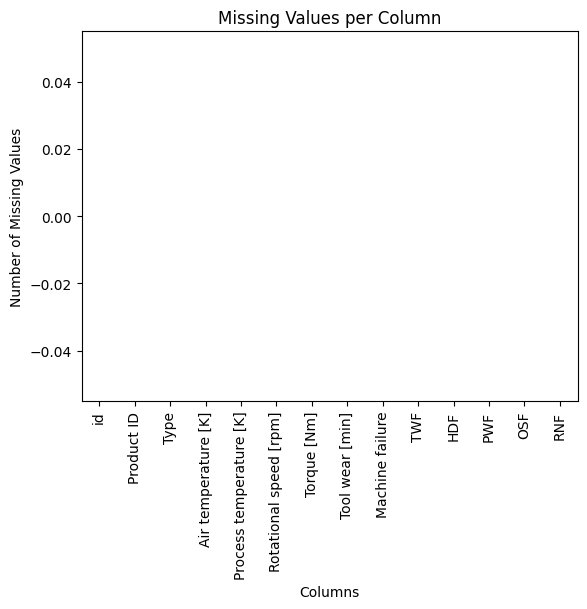

In [10]:
# Visualizing the missing values
plt.figure()
missing_data.plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

## Insights for Missing Values/Null Values
No missing values found

### What did you know about your dataset?

* The dataset consists of 136,429 records and 14 features.
* The data contains a mix of numerical, categorical, and binary variables, representing machine identifiers, operational parameters, and failure indicators.
* No missing values were found in any of the columns, indicating good data quality and eliminating the need for imputation.
* Failure-type variables (TWF, HDF, PWF, OSF, RNF) are binary and rare, representing specific causes of machine failure.


## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
data.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [12]:
# Dataset Describe
data.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Variables Description


* id :	Unique identifier for each record
* Product ID : Unique identifier assigned to each machine or product
* Type : Type/category of the machine (e.g., L, M, H)
* Air temperature [K]: Ambient air temperature around the machine in Kelvin
* Process temperature [K]: Temperature of the machine process in Kelvin
* Rotational speed [rpm]:	Speed at which the machine rotates, measured in revolutions per minute
* Torque [Nm]: Torque applied by the machine during operation, measured in Newton-meters
* Tool wear [min]: Duration of tool usage indicating wear level, measured in minutes
* Machine failure: Target variable indicating whether a machine failure occurred (1 = Yes, 0 = No)
* TWF: Tool Wear Failure indicator (1 = failure due to tool wear, 0 = otherwise)
* HDF(Heat Dissipation Failure indicator): Happens if the temperature difference between the air and process is too small and the machine speed is below a certain threshold.
* PWF(Power Failure indicator): Occurs when the power required for the process calculated from torque and speed,falls outside of a defined acceptable range.
* OSF(Overstrain Failure indicator): Occurs if the combined effect of tool wear and torque exceeds specific limits based on the product quality
* RNF(Random Failure indicator): Represents a small probability of failure occuring randomly, independent of other process parameters.

### Check Unique Values for each variable.

In [13]:
data.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [14]:
# Check Unique Values for each variable.
print('Unique values in id column:',data['id'].unique())
print('Unique values in Product ID column:',data['Product ID'].unique())
print('Unique values in Type column:',data['Type'].unique())
print('Unique values in Air Temperature column:',data['Air temperature [K]'].unique())
print('Unique values in Process Temperature column:',data['Process temperature [K]'].unique())
print('Unique values in Rotatioinal speed column:',data['Rotational speed [rpm]'].unique())
print('Unique values in Torque column:',data['Torque [Nm]'].unique())
print('Unique values in Tool wear column:',data['Tool wear [min]'].unique())
print('Unique values in Machine failure column:',data['Machine failure'].unique())
print('Unique values in TWF column:',data['TWF'].unique())
print('Unique values in HDF column:',data['HDF'].unique())
print('Unique values in PWF column:',data['PWF'].unique())
print('Unique values in OSF column:',data['OSF'].unique())
print('Unique values in RNF column:',data['RNF'].unique())



Unique values in id column: [     0      1      2 ... 136426 136427 136428]
Unique values in Product ID column: ['L50096' 'M20343' 'L49454' ... 'M18739' 'L50940' 'L48036']
Unique values in Type column: ['L' 'M' 'H']
Unique values in Air Temperature column: [300.6   302.6   299.3   301.    298.    298.4   299.6   298.7   297.7
 300.5   301.5   301.4   297.1   298.5   297.6   300.4   303.5   298.6
 300.9   297.2   298.3   297.4   301.3   300.2   300.1   297.8   300.7
 300.8   299.2   299.7   302.5   301.8   296.7   302.4   298.1   301.9
 299.1   299.    299.8   298.9   297.3   297.9   298.8   300.    302.3
 297.5   303.9   301.7   303.7   301.2   303.3   303.6   300.3   302.1
 299.5   299.4   302.2   297.    298.2   304.    303.1   296.9   301.1
 295.5   302.    304.2   303.4   296.1   302.9   301.6   304.1   303.
 295.6   302.7   296.8   296.2   303.8   299.9   295.7   303.2   296.3
 295.9   295.8   302.8   296.6   296.5   296.4   304.3   296.    295.4
 304.4   295.3   300.98  297.095 3

## 3. ***Data Wrangling***

### Data Wrangling Code

In [15]:
# Write your code to make your dataset analysis ready.
data.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [16]:
data.dtypes

,0
id,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64


In [17]:
# List of binary columns
binary_cols = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Convert to boolean
data[binary_cols] = data[binary_cols].astype(bool)

# Verify data types
data[binary_cols].dtypes


,0
Machine failure,bool
TWF,bool
HDF,bool
PWF,bool
OSF,bool
RNF,bool


In [18]:
data.dtypes

,0
id,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,bool
TWF,bool


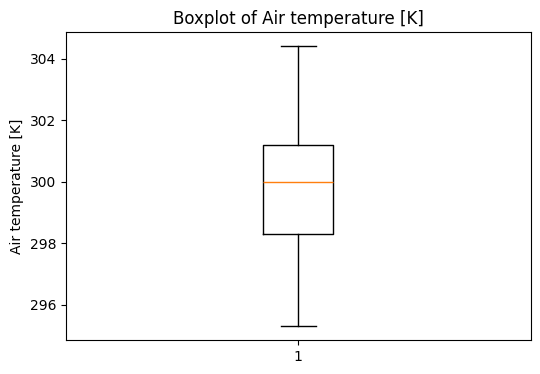

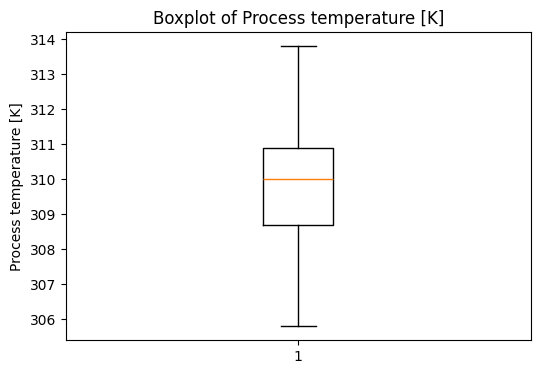

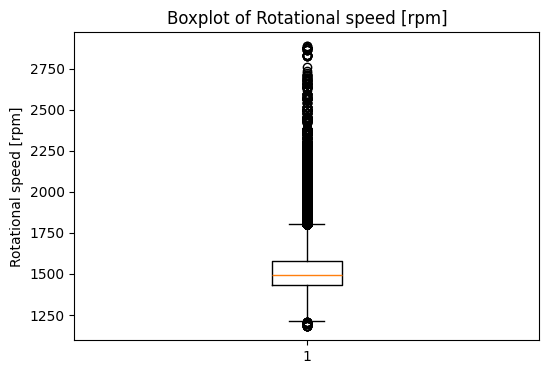

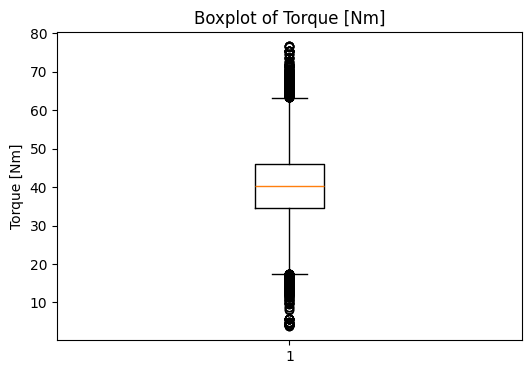

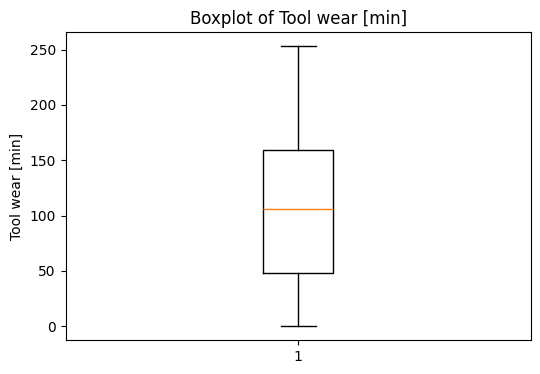

In [19]:
import matplotlib.pyplot as plt

numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


### What all manipulations have you done and insights you found?

###**Finding and handling missing values**
* No Missing values found
###**Checking data types of column and converting the data type of the column as per the data in the column**
* Convert binary columns(Machine failure, TWF, HDF, PWF, OSF, RNF) to boolean.
###**Detecting Outliers**

1. Air Temperature : Very few or no extreme outliers are observed.
2. Process Temperature: Slightly higher median than air temperature and few outliers
3. Rotational Speed:Shows wide spread and multiple outliers.Presence of extreme values indicates varying operational loads.Outliers may correspond to high-stress or failure-prone conditions.
4. Torque: Displays significant variability with visible outliers.
5. Tool wear: Several high-end outliers Indicates tools are often used close to or beyond typical wear limits.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### **Chart - 1 Histogram – Air Temperature [K]**

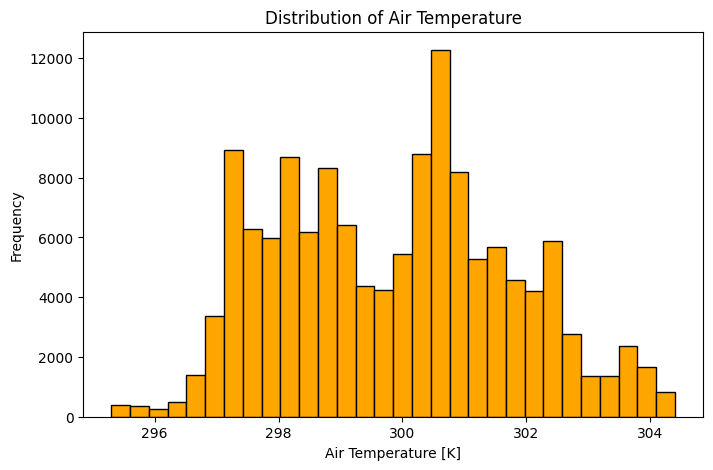

In [20]:
# Chart - 1 visualization code
air_temp = data['Air temperature [K]']
plt.figure(figsize=(8,5))
plt.hist(air_temp,bins=30,color='orange',edgecolor='black')
plt.title('Distribution of Air Temperature')
plt.xlabel('Air Temperature [K]')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

To understand the distribution and operating range.

##### 2. What is/are the insight(s) found from the chart?

* Temperature is normally distributed and stable.
* No abnormal fluctuations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The positive impact of the insight is that the stable environment reduces unexpected failures.
* There are no insights that may lead to negative growth as stable enviornment is beneeficial.

#### **Chart - 2 Histogram – Process Temperature [K]**

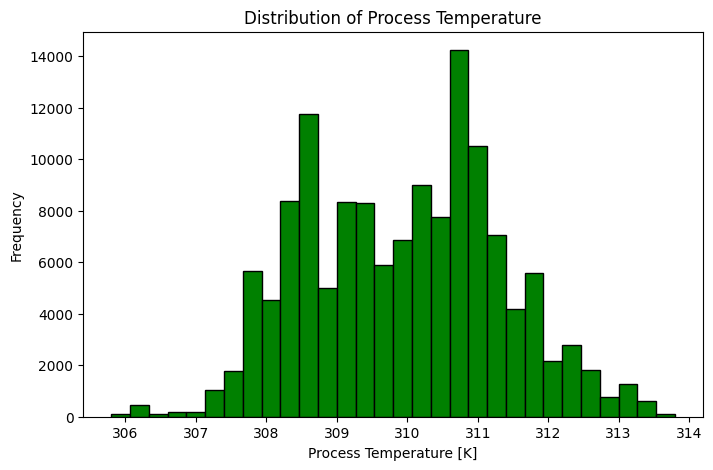

In [21]:
# Chart - 2 visualization code
process_temp=data['Process temperature [K]']
plt.figure(figsize=(8,5))
plt.hist(process_temp,bins=30,color='green',edgecolor='black')
plt.xlabel('Process Temperature [K]')
plt.ylabel('Frequency')
plt.title('Distribution of Process Temperature')
plt.show()

##### 1. Why did you pick the specific chart?

To analyze process heat behavior.

##### 2. What is/are the insight(s) found from the chart?

* Slightly higher than air temperature.
* Controlled process conditions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insight will create a positive business impact as predictable process temperature improves equipment life.

#### **Chart - 3 Boxplot – Rotational Speed [rpm]**

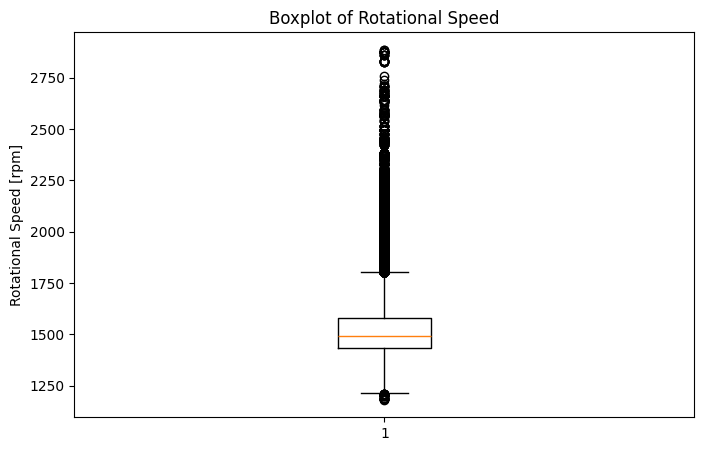

In [22]:
rot_speed=data['Rotational speed [rpm]']
plt.figure(figsize=(8,5))
plt.boxplot(rot_speed)
plt.title('Boxplot of Rotational Speed')
plt.ylabel('Rotational Speed [rpm]')
plt.show()

##### 1. Why did you pick the specific chart?

Best for detecting outliers and spread.

##### 2. What is/are the insight(s) found from the chart?

* Wide variation with extreme outliers.
* Indicates high operational stress periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

* The positive impact is that it helps identify risky operating ranges.
* The negative insight may be that the extreme RPM can accelerate wear and failures.

#### **Chart - 4 Boxplot – Torque [Nm]**


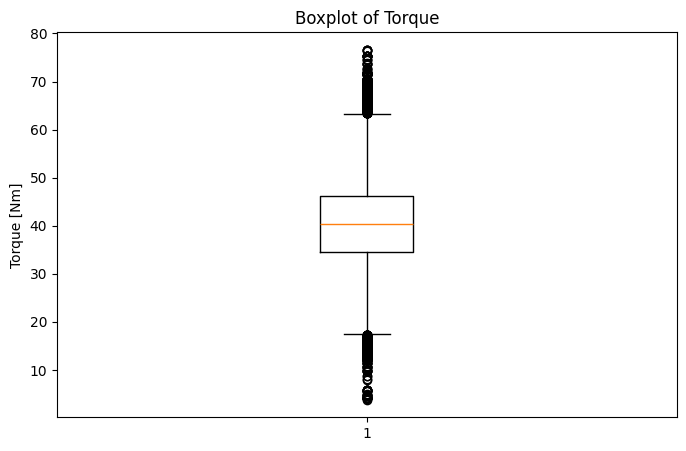

In [23]:
# Chart - 4 visualization code
trq=data['Torque [Nm]']
plt.figure(figsize=(8,5))
plt.boxplot(trq)
plt.title('Boxplot of Torque')
plt.ylabel('Torque [Nm]')
plt.show()


##### 1. Why did you pick the specific chart?

To observe mechanical load variability.

##### 2. What is/are the insight(s) found from the chart?

High torque outliers present.

Suggest overload conditions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positve Impact: Enables preventive load control.

Negative Impact: overload leads to component damage.

####**Chart - 5 Count Plot – Machine Failure**

/tmp/ipython-input-2979676224.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Machine failure', palette=colors)


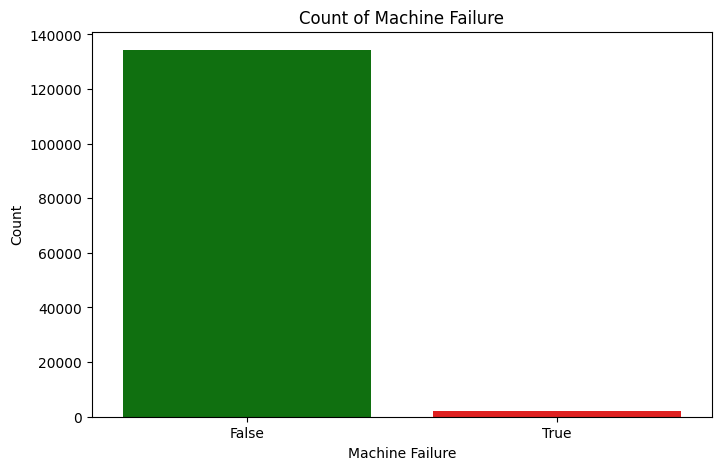

In [24]:
# Chart - 5 visualization code
plt.figure(figsize=(8,5))
# Define a palette mapping boolean values to colors with string keys
colors = {'False': 'green', 'True': 'red'} # Assuming 'False' for no failure, 'True' for failure
sns.countplot(data=data, x='Machine failure', palette=colors)
plt.title('Count of Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

To analyze class distribution.

##### 2. What is/are the insight(s) found from the chart?

Severe class imbalance.

Failures are rare events.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact: Encourages predictive maintenance focus.

Negative Impact: There is no negative impact but modeling must handle imbalance.

#### **Chart - 6 Boxplot – Torque vs Machine Failure**

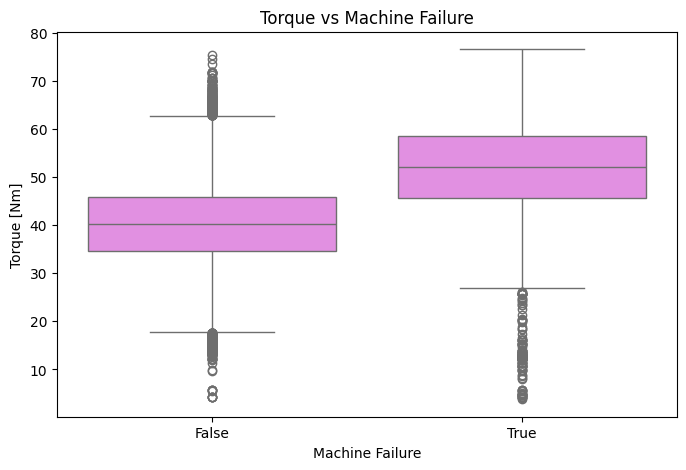

In [25]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Machine failure', y='Torque [Nm]',color='violet')
plt.title('Torque vs Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Torque [Nm]')
plt.show()

##### 1. Why did you pick the specific chart?

To compare torque under failure vs non-failure.

##### 2. What is/are the insight(s) found from the chart?

* Non-failure cases are mostly concentrated within a lower and stable torque range.
* Higher torque during failures.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact : Torque threshold setting can reduce breakdowns.

Negative Impact: Ignoring torque limits increases downtime.

#### **Chart - 7 Boxplot - Tool Wear vs Machine Failure**

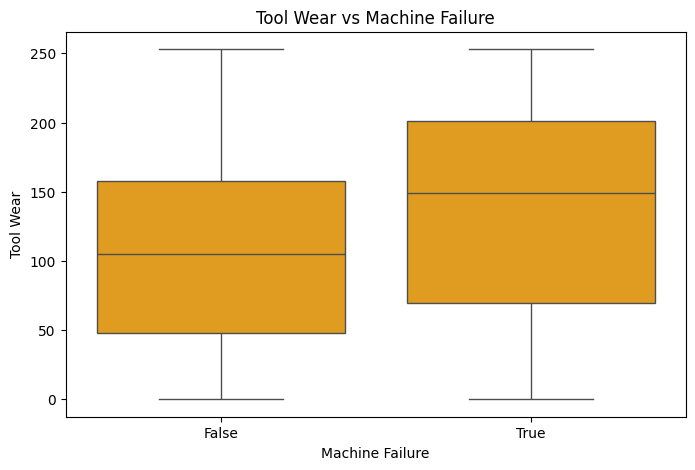

In [26]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Machine failure', y='Tool wear [min]',color='orange')
plt.title('Tool Wear vs Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Tool Wear')
plt.show()


##### 1. Why did you pick the specific chart?

To analyze wear impact on failure.

##### 2. What is/are the insight(s) found from the chart?

Failures occur at higher tool wear levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Enables timely tool replacement.

Negative Impact: Delayed replacement increases costs.



#### **Chart - 8  Scatter Plot – Rotational Speed vs Torque**

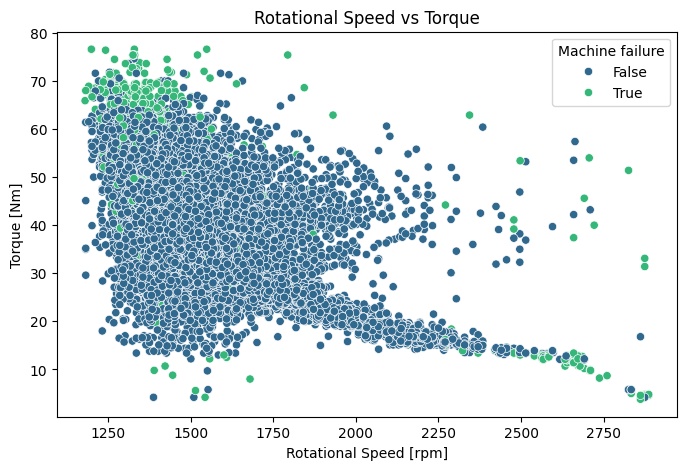

In [27]:
# Chart - 8 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', palette='viridis')
plt.title('Rotational Speed vs Torque')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.show()

##### 1. Why did you pick the specific chart?

To understand mechanical stress interaction.

##### 2. What is/are the insight(s) found from the chart?

* positive relationship between rotational speed and torque, indicating that higher speeds often require higher torque
* High speed + high torque is a risky zone.
* There is no sharp linear boundary between failure and non-failure, but failure risk clearly rises in extreme operating zones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps define safe operating regions.

Negative Impact: Unsafe combinations increase failure rate.

#### **Chart - 9 Boxplot - Type vs Machine Failure**



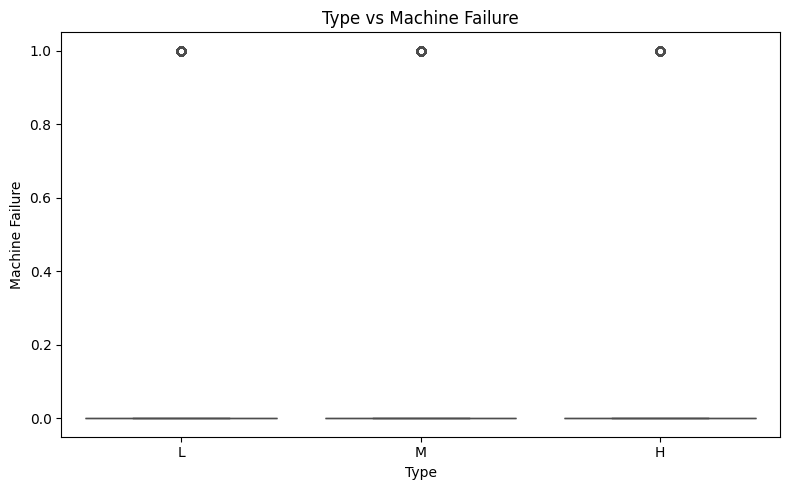

In [28]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Type', y='Machine failure',color='blue')
plt.title('Type vs Machine Failure')
plt.xlabel('Type')
plt.ylabel('Machine Failure')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

To compare failure rate across machine types.

##### 2. What is/are the insight(s) found from the chart?

* Most observations are at 0, indicating failures are rare overall.
* Since failures occur sparsely and similarly across L, M, and H, machine type by itself may not be a strong predictor of failure.
* heavily imbalanced dataset (many non-failures vs very few failures)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact:  Guides machine-specific maintenance strategies.

Negative Impact: High-failure types increase operational risk.

#### **Chart - 10 :Scatter Plot – Tool Wear vs Torque**

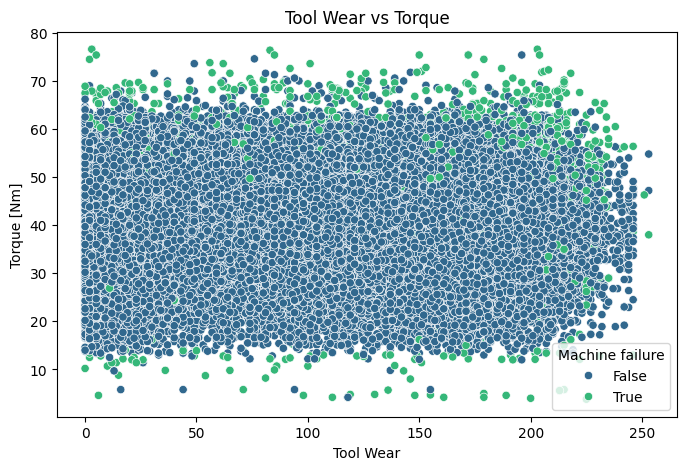

In [29]:
# Chart - 10 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Tool wear [min]', y='Torque [Nm]', hue='Machine failure', palette='viridis')
plt.title('Tool Wear vs Torque')
plt.xlabel('Tool Wear')
plt.ylabel('Torque [Nm]')
plt.show()

##### 1. Why did you pick the specific chart?

To observe wear under load.

##### 2. What is/are the insight(s) found from the chart?

* failures are not confined to only high tool wear or high torque—some failures occur even at low values.
* Torque increases with tool wear, indicating that worn tools require more effort to maintain performance.
* Machine failures occur at both low and high tool wear, though they seem slightly more frequent at higher tool wear (>150 min).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Predicts wear-related failure progression.

Negative Impact: Worn tools under high load fail faster.

#### **Chart - 11 Violin Plot – Rotational Speed vs Machine Failure**

/tmp/ipython-input-3741984845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Machine failure', y='Rotational speed [rpm]', palette='viridis')


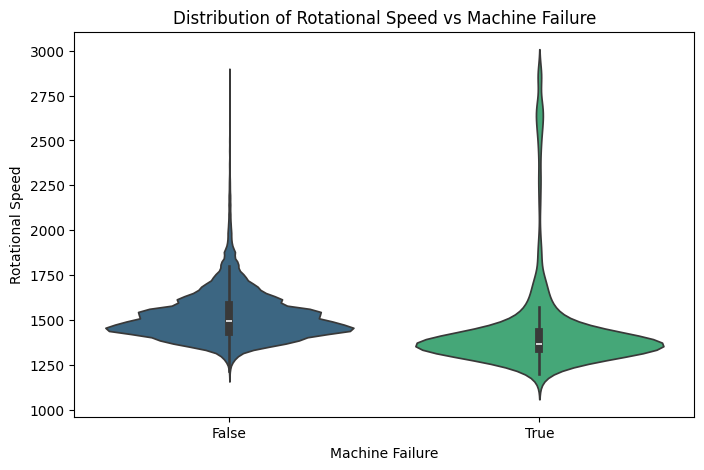

In [30]:
# Chart - 11 visualization code
plt.figure(figsize=(8,5))
sns.violinplot(data=data, x='Machine failure', y='Rotational speed [rpm]', palette='viridis')
plt.title('Distribution of Rotational Speed vs Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Rotational Speed')
plt.show()

##### 1. Why did you pick the specific chart?

Shows distribution + density.

##### 2. What is/are the insight(s) found from the chart?

* Machines that did not fail (False) mostly operate around 1400–1500 RPM, with some outliers up to ~1750 RPM.
* Machines that failed (True) have a lower median speed (~1350 RPM) but a wider spread, ranging from ~1200 to 1600 RPM.
* Rotational speed is potentially a strong indicator of failure, especially if it drops below 1400 RPM or spikes unusually.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps set RPM safety limits.

Negative Impact: Uncontrolled RPM increases failures.

#### **Chart - 12 Scatter Plot – Speed vs Torque (Hue: Machine Failure)**


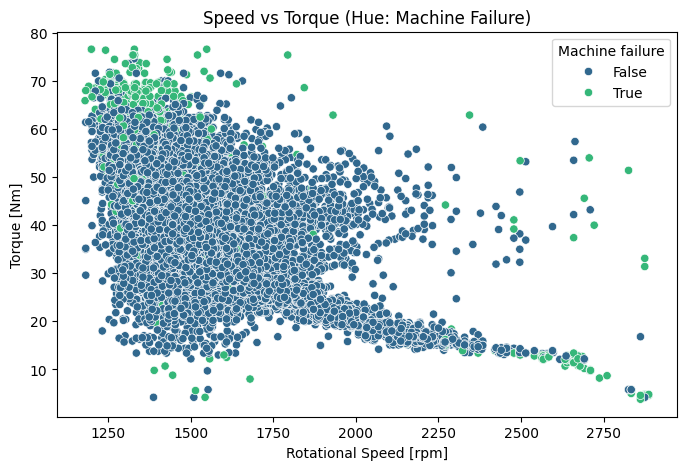

In [31]:
# Chart - 12 visualization code
plt.figure(figsize=(8,5))
sns.scatterplot(data=data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Machine failure', palette='viridis')
plt.title('Speed vs Torque (Hue: Machine Failure)')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.show()

##### 1. Why did you pick the specific chart?

Adds failure context to interaction.


##### 2. What is/are the insight(s) found from the chart?

* Negative correlation between rotational speed and torque—higher speeds generally correspond to lower torque.
* Failures concentrate in high speed–high torque region.
* The dense blue cluster (no failure) lies roughly in the mid-speed (1400–2000 rpm) and mid-torque (20–50 Nm) range, suggesting this is the stable operating zone.
* Failures are not perfectly separable from non-failures—there is significant overlap, meaning speed and torque alone cannot fully explain failures.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Directly actionable for operational controls.

Negative Impact: Ignoring this region increases breakdowns.



#### **Chart - 13 Boxplot – Tool Wear vs Failure Type**

/tmp/ipython-input-668277563.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Type', y='Tool wear [min]', palette='viridis')


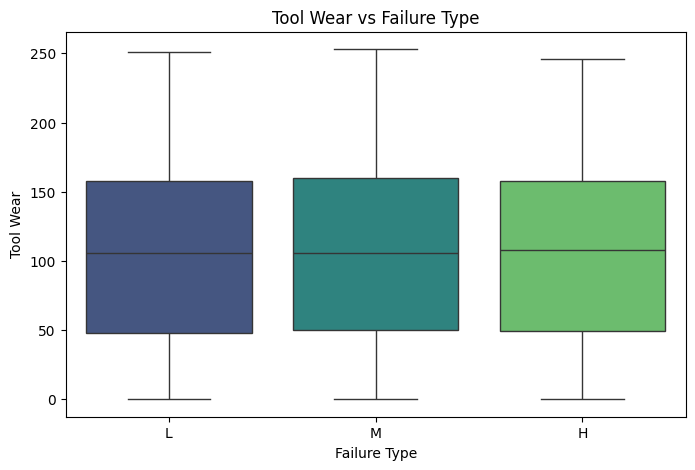

In [32]:
# Chart - 13 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Type', y='Tool wear [min]', palette='viridis')
plt.title('Tool Wear vs Failure Type')
plt.xlabel('Failure Type')
plt.ylabel('Tool Wear')
plt.show()

##### 1. Why did you pick the specific chart?

To compare wear impact across failure modes.

##### 2. What is/are the insight(s) found from the chart?

* Tool Wear Failure occurs at highest wear values.
* Tool wear alone does not strongly differentiate among failure types.
* All three failure types have a median around ~100–110, indicating failures typically occur at moderate tool wear, not only at extreme wear levels.
* The strong overlap in interquartile ranges suggests no clear threshold of tool wear that uniquely triggers a specific failure type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Enables failure-type-specific prevention.

Negative Impact: Ignoring wear leads to cascading failures.

#### **Chart - 14 - Correlation Heatmap**

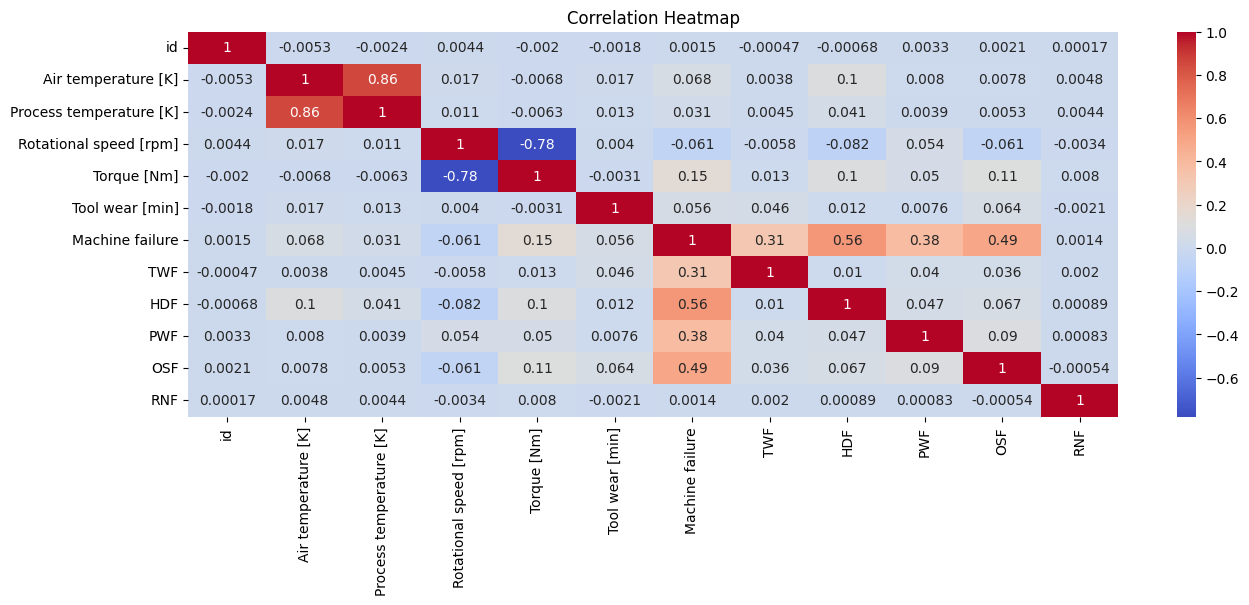

In [33]:
# Correlation Heatmap visualization code
plt.figure(figsize=(15,5))
# Select only numeric columns for correlation calculation
numeric_data = data.select_dtypes(include=[np.number, np.bool_])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Best for multivariate numeric relationships.

##### 2. What is/are the insight(s) found from the chart?

Strong relationships between torque, speed, and tool wear.

#### **Chart - 15 - Pair Plot**

<Figure size 1500x1000 with 0 Axes>

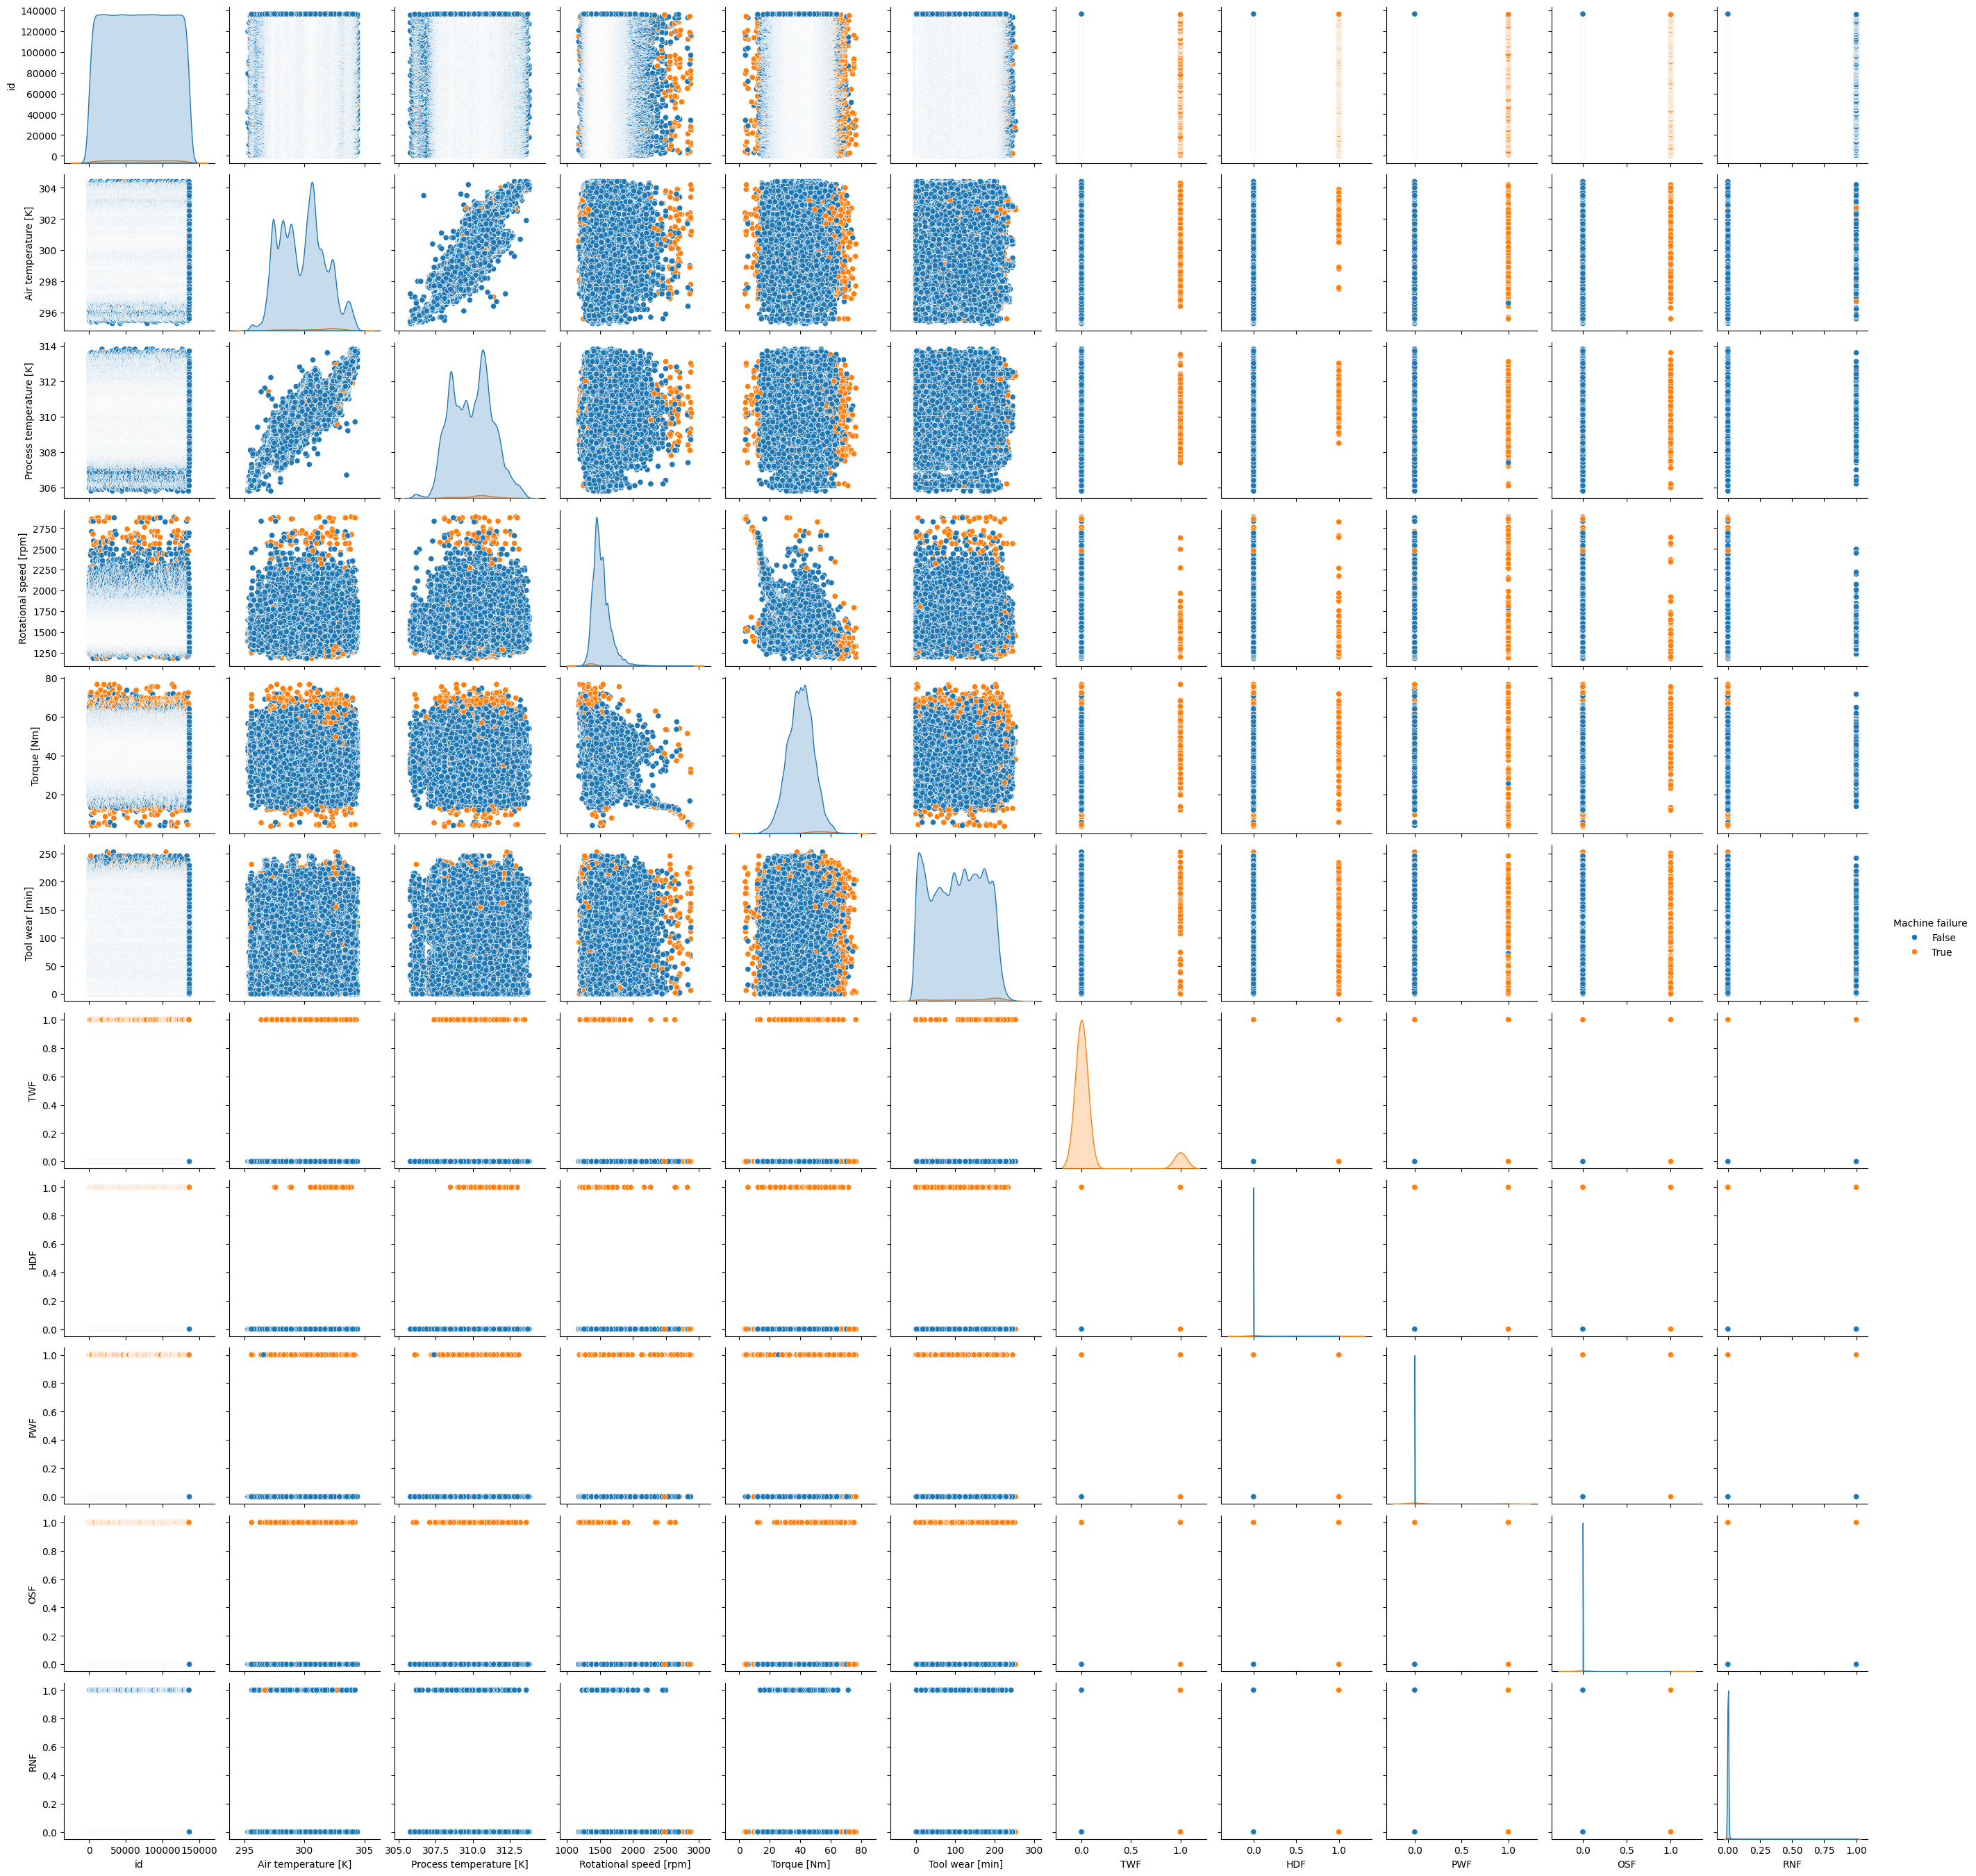

In [34]:
# Pair Plot visualization code
plt.figure(figsize=(15,10))
sns.pairplot(data, hue='Machine failure')
plt.show()

##### 1. Why did you pick the specific chart?

Visualizes multiple relationships together.



##### 2. What is/are the insight(s) found from the chart?

Failure points cluster at extreme values.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?


Based on the EDA findings, the client should continuously monitor key operational parameters such as rotational speed, torque, and tool wear, as these variables show strong relationships with machine failures. Setting safe operating thresholds and real-time alerts for extreme values can help prevent breakdowns.
Additionally, maintenance activities should be shifted from fixed schedules to condition-based maintenance, especially for tool replacement, as high tool wear is closely associated with failures. Machine-type-specific maintenance strategies should be implemented since failure behavior varies across machine types. These actions will help the client reduce downtime, extend machine lifespan, and improve overall operational efficiency.
By monitoring critical machine parameters and applying condition-based, machine-specific maintenance strategies, the client can proactively prevent failures and achieve the business objective.

# **Conclusion**

The project highlights the importance of EDA in uncovering meaningful patterns, identifying operational risks, and enabling informed business decisions before applying machine learning techniques.The visual and statistical analysis provided actionable insights that support a shift from reactive to proactive maintenance strategies, such as condition-based maintenance and real-time monitoring. Overall, this EDA phase laid a strong foundation for building reliable machine learning models and demonstrated how data-driven insights can help reduce downtime, maintenance costs, and operational risks in an industrial environment.